# Final results charts: GARCH vs. Transformer vs. actual moves

One chart per metal, same test period (2023-04-12 to 2026-08-05). Actual daily moves in muted gray (context, not a competing series), GARCH and the transformer in a validated, colorblind-safe blue/orange pair, with RMSE quoted directly in the legend.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from arch import arch_model

import sys
sys.path.insert(0, "../src")
from windowing import create_windows
from model import VolatilityTransformer

WINDOW_SIZE = 30
GARCH_TEST_START = "2023-04-12"
GARCH_TEST_END = "2026-08-05"

# Validated palette (dataviz skill): slots 1 (blue) and 2 (orange) are a
# pre-validated adjacent pair - worst adjacent CVD dE 9.1 (>=8 target),
# worst adjacent normal-vision dE 19.6 (>=15 floor), both light mode.
COLOR_ACTUAL = "#898781"       # muted ink - context line, not a competing series
COLOR_GARCH = "#2a78d6"        # categorical slot 1 (blue)
COLOR_TRANSFORMER = "#eb6834"  # categorical slot 2 (orange)
COLOR_GRID = "#e1e0d9"
COLOR_SURFACE = "#fcfcfb"
COLOR_TEXT_SECONDARY = "#52514e"

## Compute actual / GARCH / transformer series for one metal

Reuses the exact same logic as notebooks 14 and 15 (windowing, date-aligned split, GARCH refit, checkpoint loading) so these numbers match the final scoreboard exactly.

In [2]:
def compute_results(csv_path, checkpoint_path):
    df = pd.read_csv(csv_path, skiprows=[1, 2], index_col=0, parse_dates=True)
    returns = df["Close"].pct_change().dropna() * 100

    X, y, dates = create_windows(returns, WINDOW_SIZE)
    test_mask = (dates >= GARCH_TEST_START) & (dates <= GARCH_TEST_END)
    X_test, y_test, dates_test = X[test_mask], y[test_mask], dates[test_mask]

    checkpoint = torch.load(checkpoint_path, weights_only=False)
    model = VolatilityTransformer()
    model.load_state_dict(checkpoint["state_dict"])
    model.eval()

    X_test_norm = (X_test - checkpoint["train_mean"]) / checkpoint["train_std"]
    X_test_tensor = torch.tensor(X_test_norm, dtype=torch.float32).unsqueeze(-1)
    with torch.no_grad():
        predictions_transformer = model(X_test_tensor).numpy()
    rmse_transformer = np.sqrt(np.mean((predictions_transformer - y_test) ** 2))

    split_idx = int(len(returns) * 0.8)
    split_date = returns.index[split_idx]
    garch_model = arch_model(returns, mean="Constant", vol="Garch", p=1, q=1, dist="normal")
    garch_result = garch_model.fit(last_obs=split_date, disp="off")
    garch_forecasts = garch_result.forecast(start=split_date, horizon=1, reindex=False)
    garch_volatility = np.sqrt(garch_forecasts.variance["h.1"])
    next_day_return = returns.shift(-1).loc[garch_volatility.index]
    garch_realized = next_day_return.abs()
    valid = garch_volatility.notna() & garch_realized.notna()
    garch_volatility, garch_realized = garch_volatility[valid], garch_realized[valid]
    rmse_garch = np.sqrt(np.mean((garch_volatility - garch_realized) ** 2))

    return {
        "dates_test": dates_test,
        "y_test": y_test,
        "predictions_transformer": predictions_transformer,
        "rmse_transformer": rmse_transformer,
        "garch_volatility": garch_volatility,
        "rmse_garch": rmse_garch,
    }


gold_results = compute_results("../data/gold_futures.csv", "../models/gold_transformer.pt")
silver_results = compute_results("../data/silver_futures.csv", "../models/silver_transformer.pt")

print(f"Gold   - GARCH RMSE: {gold_results['rmse_garch']:.4f}  Transformer RMSE: {gold_results['rmse_transformer']:.4f}")
print(f"Silver - GARCH RMSE: {silver_results['rmse_garch']:.4f}  Transformer RMSE: {silver_results['rmse_transformer']:.4f}")

Gold   - GARCH RMSE: 0.9032  Transformer RMSE: 0.9046
Silver - GARCH RMSE: 2.0044  Transformer RMSE: 2.0116


## The chart function

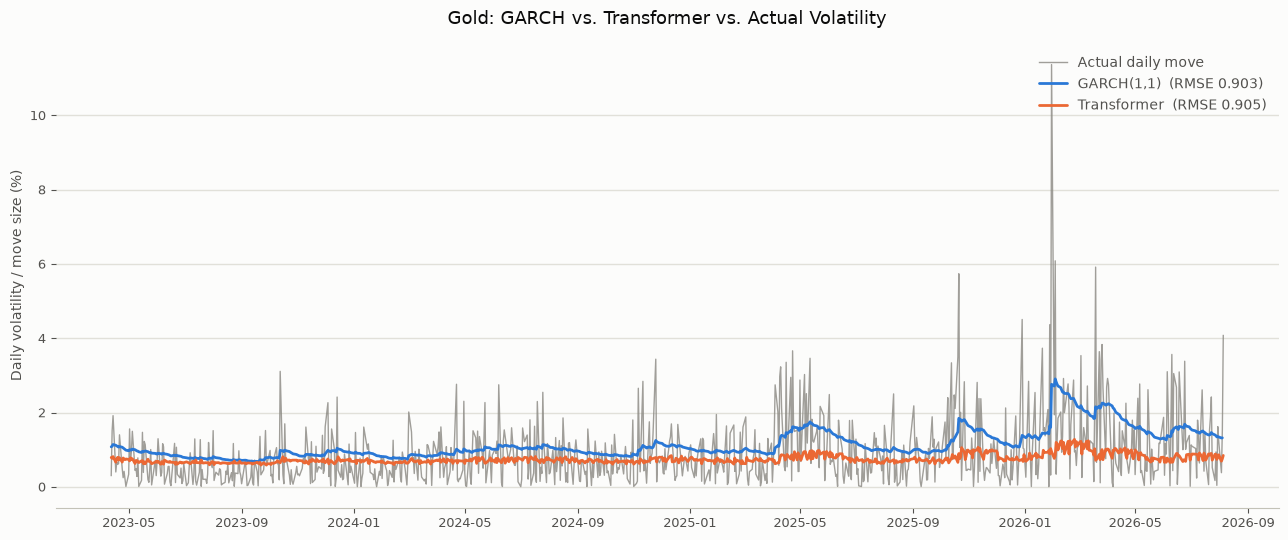

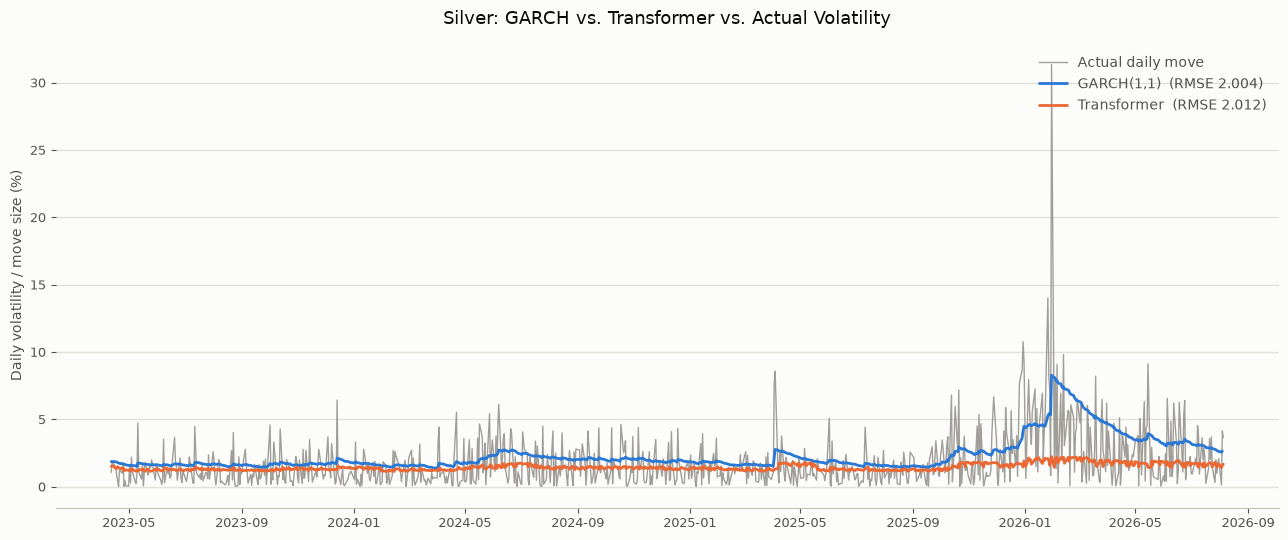

In [3]:
def plot_metal(results, metal_name):
    fig, ax = plt.subplots(figsize=(13, 5.5))
    fig.patch.set_facecolor(COLOR_SURFACE)
    ax.set_facecolor(COLOR_SURFACE)

    ax.plot(
        results["dates_test"], results["y_test"],
        color=COLOR_ACTUAL, linewidth=1, alpha=0.8, label="Actual daily move",
    )
    ax.plot(
        results["garch_volatility"].index, results["garch_volatility"].values,
        color=COLOR_GARCH, linewidth=2, solid_capstyle="round",
        label=f"GARCH(1,1)  (RMSE {results['rmse_garch']:.3f})",
    )
    ax.plot(
        results["dates_test"], results["predictions_transformer"],
        color=COLOR_TRANSFORMER, linewidth=2, solid_capstyle="round",
        label=f"Transformer  (RMSE {results['rmse_transformer']:.3f})",
    )

    ax.set_title(f"{metal_name}: GARCH vs. Transformer vs. Actual Volatility", color="#0b0b0b", fontsize=13, pad=14)
    ax.set_ylabel("Daily volatility / move size (%)", color=COLOR_TEXT_SECONDARY, fontsize=10)

    ax.grid(axis="y", color=COLOR_GRID, linewidth=1, zorder=0)
    ax.set_axisbelow(True)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color("#c3c2b7")
    ax.tick_params(colors=COLOR_TEXT_SECONDARY, labelsize=9)

    legend = ax.legend(loc="upper right", frameon=False, fontsize=10, labelcolor=COLOR_TEXT_SECONDARY)

    plt.tight_layout()
    plt.show()


plot_metal(gold_results, "Gold")
plot_metal(silver_results, "Silver")